Fetching data for USDJPY=X from 2020-01-01 to 2024-12-31...
✅ Cleaned shapes: X=(1279, 5), y=(1279,)

--- Tuning Model ---
TP=10 | Best F1=0.5752 | Params={'svm__C': 10, 'svm__kernel': 'linear'}
TP=14 | Best F1=0.5825 | Params={'svm__C': 10, 'svm__kernel': 'linear'}
TP=20 | Best F1=0.6101 | Params={'svm__C': 1, 'svm__kernel': 'linear'}

=== FINAL MODEL ===
Best Parameters: {'svm__C': 1, 'svm__kernel': 'linear', 'rsi_timeperiod': 20}
Best F1 Score: 0.6101

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.53      0.55      0.54       546
           1       0.64      0.62      0.63       710

    accuracy                           0.59      1256
   macro avg       0.59      0.59      0.59      1256
weighted avg       0.59      0.59      0.59      1256



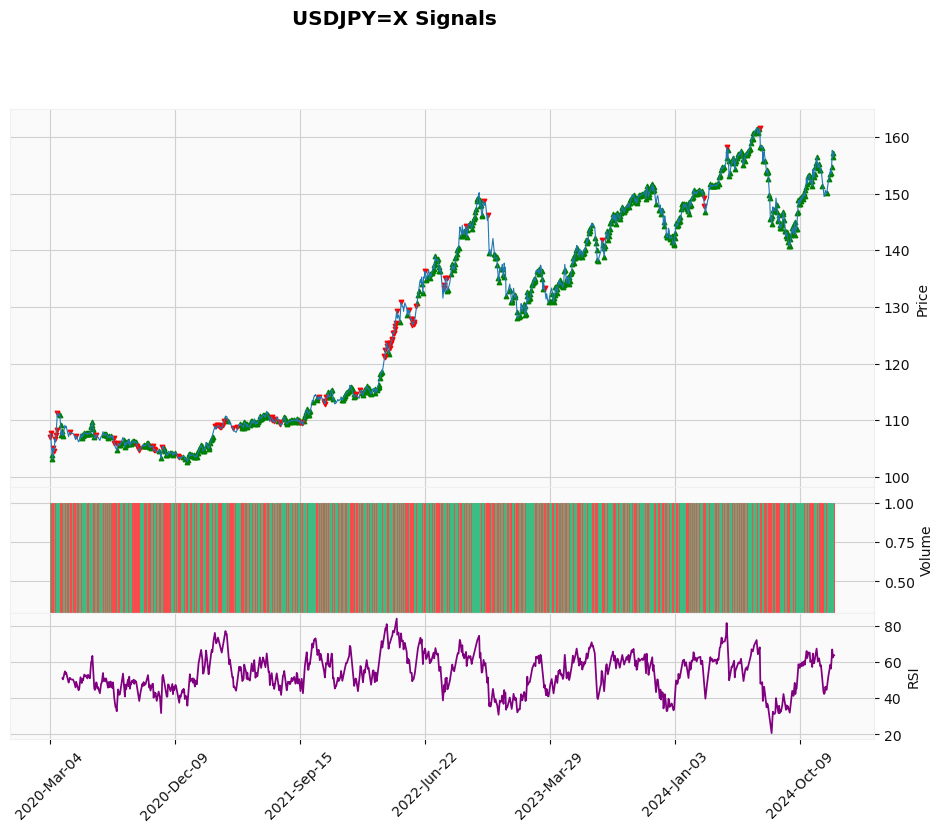


=== BACKTEST RESULTS ===
Initial Capital: $10,000.00
Final Equity: $26,397.43
Total Strategy Return: 163.97%
Buy & Hold Return: 46.78%
Max Drawdown: -8.56%
Number of Trades: 337
Win Rate: 53.63%


/tmp/ipykernel_6019/2366314170.py:221: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['equity'].iloc[0] = initial_capital


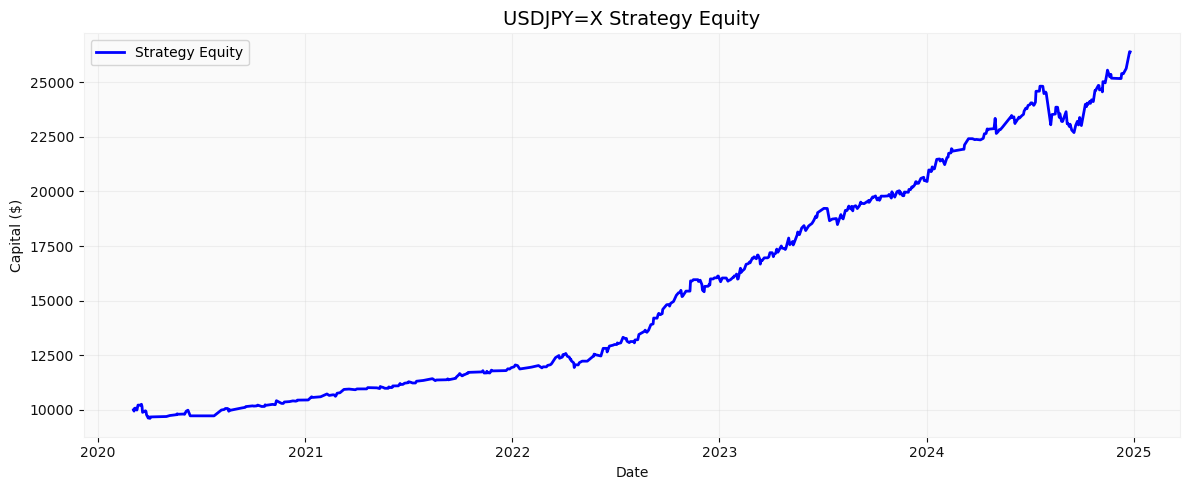


✅ System Ready for Live Trading!

📊 TRADE PLAN FOR USDJPY=X
--------------------------------
Probability Up: 66.6%
Direction: 📈 BUY / LONG
Entry Price: 162.027
Stop-Loss: 161.2527 (77.43 pips risk)
Take-Profit: 163.1885
Risk/Reward Ratio: 1 : 1.5
Capital: $10,000.00
Risk per Trade: 1.0% = $100.00
Position Size: 129.15 lots/units
Potential Profit: $150.01



In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import talib
import mplfinance as mpf
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report


# ----------------------
# ⚙️ CONFIG SETTINGS
# ----------------------
RUN_BACKTEST = True          # Set False for real trading only
PLOT_EQUITY_CURVE = True
PLOT_PRICE_WITH_SIGNALS = True

# Risk Management Settings
RISK_PER_TRADE_PCT = 1.0     # Risk max 1% of capital per trade
REWARD_RATIO = 1.5            # Target profit = 1.5 × risk
SL_MULTIPLIER = 1.0           # Stop-loss distance = 1 × ATR
TP_MULTIPLIER = 1.5           # Take-profit distance = 1.5 × ATR
SIGNAL_THRESHOLD = 0.55       # Probability threshold for entry


# ----------------------
# 1. Feature Engineering
# ----------------------
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, timeperiod=14):
        self.timeperiod = timeperiod

    def fit(self, X, y=None):
        return self

    def transform(self, df):
        df_features = df.copy()
        close = np.asarray(df_features['Close']).ravel()
        high = np.asarray(df_features['High']).ravel()
        low = np.asarray(df_features['Low']).ravel()
        volume = np.asarray(df_features['Volume']).ravel()

        # Core indicators
        df_features['MA20'] = talib.SMA(close, timeperiod=20)
        df_features['ATR'] = talib.ATR(high, low, close, timeperiod=14)
        df_features['RSI'] = talib.RSI(close, timeperiod=self.timeperiod)
        df_features['CCI'] = talib.CCI(high, low, close, timeperiod=20)

        # Returns & changes
        df_features['PriceChange'] = np.append(np.nan, np.diff(close) / close[:-1])
        df_features['VolChange'] = np.append(np.nan, np.diff(volume) / volume[:-1])

        # Lagged features
        for lag in [1, 2, 3]:
            df_features[f'RSI_lag{lag}'] = df_features['RSI'].shift(lag)
            df_features[f'VolChange_lag{lag}'] = df_features['VolChange'].shift(lag)

        feature_cols = [
            'MA20', 'ATR', 'RSI', 'CCI', 'PriceChange', 'VolChange',
            'RSI_lag1', 'RSI_lag2', 'RSI_lag3',
            'VolChange_lag1', 'VolChange_lag2', 'VolChange_lag3'
        ]
        return df_features[feature_cols]


# ----------------------
# 2. Data Preparation
# ----------------------
def prepare_forex_dataset(ticker, start, end, max_feature_lookback=20, max_label_lookahead=3, max_lag=3):
    print(f"Fetching data for {ticker} from {start} to {end}...")
    try:
        df = yf.download(ticker, start=start, end=end, progress=False)
        if df.empty:
            print("❌ No data retrieved.")
            return None, None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        df.sort_index(inplace=True)
        df['Volume'] = df['Volume'].replace(0, 1e-6)
    except Exception as e:
        print(f"❌ Error fetching data: {e}")
        return None, None

    close = np.asarray(df['Close']).ravel()
    future_return = pd.Series(close).pct_change(max_label_lookahead).shift(-max_label_lookahead).values
    df['future_return'] = future_return
    df['label'] = np.where(future_return > 0, 1, 0)

    required_min_len = max_feature_lookback + max_lag + max_label_lookahead
    if len(df) < required_min_len:
        print(f"❌ Need at least {required_min_len} rows, got {len(df)}")
        return None, None

    temp_sma = talib.SMA(close, timeperiod=max_feature_lookback + max_lag)
    first_valid_idx = pd.Series(temp_sma, index=df.index).first_valid_index()
    if first_valid_idx is None:
        print("❌ Could not determine valid start index")
        return None, None

    df_clean = df.loc[first_valid_idx:].dropna(subset=['future_return', 'label']).copy()
    y = df_clean['label'].astype(int)
    X_raw = df_clean.drop(columns=['label', 'future_return'])
    print(f"✅ Cleaned shapes: X={X_raw.shape}, y={y.shape}")
    return X_raw, y


# ----------------------
# 3. Generate Signals
# ----------------------
def generate_signals(model, X_features, threshold=0.55):
    proba = model.predict_proba(X_features)[:, 1]
    signal = np.zeros(len(proba))
    signal[proba > threshold] = 1
    signal[proba < (1 - threshold)] = -1
    return pd.Series(signal, index=X_features.index, name='signal')


# ----------------------
# 4. Risk Management Engine
# ----------------------
def calculate_risk_levels(entry_price, atr, direction="long"):
    sl_distance = atr * SL_MULTIPLIER
    tp_distance = sl_distance * REWARD_RATIO

    if direction.lower() == "long":
        stop_loss = entry_price - sl_distance
        take_profit = entry_price + tp_distance
    else:
        stop_loss = entry_price + sl_distance
        take_profit = entry_price - tp_distance

    return {
        "entry": round(entry_price, 4),
        "stop_loss": round(stop_loss, 4),
        "take_profit": round(take_profit, 4),
        "risk_pips": round(sl_distance * 100, 2)  # For JPY pairs
    }


def calculate_position_size(capital, risk_pct, entry_price, stop_loss):
    risk_amount = capital * (risk_pct / 100)
    risk_per_unit = abs(entry_price - stop_loss)
    if risk_per_unit == 0:
        return 0
    size = risk_amount / risk_per_unit
    return round(size, 2)


# ----------------------
# 5. Real Trading Signal + Risk Output
# ----------------------
def get_live_trade_plan(ticker, model, feature_engineer, capital=10000, threshold=0.55):
    try:
        data = yf.download(ticker, period="60d", interval="1d", progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data = data[["Open", "High", "Low", "Close", "Volume"]].copy()
        data["Volume"] = data["Volume"].replace(0, 1e-6)

        features = feature_engineer.transform(data).dropna()
        if features.empty:
            return "❌ Not enough data to generate plan"

        latest = features.tail(1)
        prob_up = model.predict_proba(latest)[0, 1]
        entry = data["Close"].iloc[-1]
        atr = latest["ATR"].iloc[0]

        if prob_up > threshold:
            direction = "LONG"
            risk = calculate_risk_levels(entry, atr, "long")
        elif prob_up < (1 - threshold):
            direction = "SHORT"
            risk = calculate_risk_levels(entry, atr, "short")
        else:
            return f"""--- {ticker} ---
Probability Up: {prob_up:.1%}
Action: ⏸️ HOLD / NO TRADE
Reason: Probability between thresholds"""

        size = calculate_position_size(capital, RISK_PER_TRADE_PCT, risk["entry"], risk["stop_loss"])
        risk_amount = round(capital * (RISK_PER_TRADE_PCT / 100), 2)
        potential_profit = round(size * abs(risk["take_profit"] - risk["entry"]), 2)

        plan = f"""
📊 TRADE PLAN FOR {ticker}
--------------------------------
Probability Up: {prob_up:.1%}
Direction: {'📈 BUY / LONG' if direction == 'LONG' else '📉 SELL / SHORT'}
Entry Price: {risk['entry']}
Stop-Loss: {risk['stop_loss']} ({risk['risk_pips']} pips risk)
Take-Profit: {risk['take_profit']}
Risk/Reward Ratio: 1 : {REWARD_RATIO}
Capital: ${capital:,.2f}
Risk per Trade: {RISK_PER_TRADE_PCT}% = ${risk_amount:,.2f}
Position Size: {size} lots/units
Potential Profit: ${potential_profit:,.2f}
"""
        return plan

    except Exception as e:
        return f"❌ Error generating trade plan: {e}"


# ----------------------
# 6. Backtest Engine
# ----------------------
def backtest(df_price, signals, initial_capital=10000, fee_pct=0.0002):
    data = df_price.copy()
    data['signal'] = signals
    data['position'] = data['signal'].shift(1).fillna(0)
    data['returns'] = data['Close'].pct_change().fillna(0)
    data['trade'] = data['position'].diff().abs()
    data['net_returns'] = data['position'] * data['returns'] - data['trade'] * fee_pct
    data['equity'] = initial_capital * (1 + data['net_returns']).cumprod()
    data['equity'].iloc[0] = initial_capital

    total_return = (data['equity'].iloc[-1] / initial_capital) - 1
    buy_hold_return = (data['Close'].iloc[-1] / data['Close'].iloc[0]) - 1
    drawdown = (data['equity'] / data['equity'].cummax()) - 1
    max_drawdown = drawdown.min()
    num_trades = int(data['trade'].sum())
    win_rate = (data['net_returns'][data['net_returns'] != 0] > 0).mean() if num_trades > 0 else 0

    metrics = {
        'Initial Capital': f"${initial_capital:,.2f}",
        'Final Equity': f"${data['equity'].iloc[-1]:,.2f}",
        'Total Strategy Return': f"{total_return:.2%}",
        'Buy & Hold Return': f"{buy_hold_return:.2%}",
        'Max Drawdown': f"{max_drawdown:.2%}",
        'Number of Trades': num_trades,
        'Win Rate': f"{win_rate:.2%}"
    }
    return data, metrics


# ----------------------
# 7. Plot Functions (Fixed Alignment)
# ----------------------
def plot_with_signals(df, signals, title="Price & Signals", rsi_period=14):
    # Align both data to same index first
    common_idx = df.index.intersection(signals.index)
    df_plot = df.loc[common_idx].copy()
    signals_aligned = signals.loc[common_idx]

    close = np.asarray(df_plot['Close']).ravel()
    df_plot['RSI'] = talib.RSI(close, timeperiod=rsi_period)

    # Create buy/sell markers aligned exactly
    buy = pd.Series(np.nan, index=df_plot.index)
    sell = pd.Series(np.nan, index=df_plot.index)
    buy.loc[signals_aligned[signals_aligned == 1].index] = df_plot.loc[signals_aligned == 1, 'Close']
    sell.loc[signals_aligned[signals_aligned == -1].index] = df_plot.loc[signals_aligned == -1, 'Close']

    addplots = [
        mpf.make_addplot(buy, type='scatter', marker='^', color='g', markersize=10, panel=0),
        mpf.make_addplot(sell, type='scatter', marker='v', color='r', markersize=10, panel=0),
        mpf.make_addplot(df_plot['RSI'], panel=2, color='purple', ylabel='RSI')
    ]
    plot_type = 'candle' if len(df_plot) < 800 else 'line'

    mpf.plot(
        df_plot,
        type=plot_type,
        volume=True,
        addplot=addplots,
        title=title,
        style='yahoo',
        figsize=(12, 9),
        panel_ratios=(3, 1, 1),
        warn_too_much_data=2000
    )


def plot_equity_curve(data, title="Equity Curve"):
    plt.figure(figsize=(12, 5))
    plt.plot(data['equity'], label='Strategy Equity', color='blue', linewidth=2)
    plt.title(title, fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Capital ($)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ----------------------
# Main Execution
# ----------------------
if __name__ == "__main__":
    # Trading Settings
    FOREX_PAIR = "USDJPY=X"   # "EURJPY=X" / "GBPJPY=X"
    START_DATE = "2020-01-01"
    END_DATE = "2024-12-31"
    INITIAL_CAPITAL = 10000

    # Load data
    X_raw, y = prepare_forex_dataset(FOREX_PAIR, START_DATE, END_DATE)

    if X_raw is not None and y is not None:
        print("\n--- Tuning Model ---")
        best_score = -np.inf
        best_params = {}
        timeperiods = [10, 14, 20]

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
        ])
        param_grid = {'svm__C': [0.1, 1, 10], 'svm__kernel': ['linear', 'rbf']}
        tscv = TimeSeriesSplit(n_splits=5)

        for tp in timeperiods:
            fe = FeatureEngineer(timeperiod=tp)
            X_feat = fe.transform(X_raw)
            combined = pd.concat([X_feat, y], axis=1).dropna()
            if combined.empty:
                continue
            Xc, yc = combined.drop(columns=['label']), combined['label']
            grid = GridSearchCV(model, param_grid, cv=tscv, scoring='f1', n_jobs=-1, verbose=0)
            grid.fit(Xc, yc)
            print(f"TP={tp} | Best F1={grid.best_score_:.4f} | Params={grid.best_params_}")
            if grid.best_score_ > best_score:
                best_score = grid.best_score_
                best_params = grid.best_params_.copy()
                best_params['rsi_timeperiod'] = tp

        # Final model
        print("\n=== FINAL MODEL ===")
        print(f"Best Parameters: {best_params}")
        print(f"Best F1 Score: {best_score:.4f}")
        best_tp = best_params['rsi_timeperiod']
        svm_args = {k.replace('svm__', ''): v for k, v in best_params.items() if k.startswith('svm__')}
        fe_final = FeatureEngineer(timeperiod=best_tp)
        X_final = fe_final.transform(X_raw)
        data_final = pd.concat([X_final, y], axis=1).dropna()
        Xm, ym = data_final.drop(columns=['label']), data_final['label']
        final_model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(probability=True, class_weight='balanced', random_state=42, **svm_args))
        ])
        final_model.fit(Xm, ym)
        print("\n--- Classification Report ---")
        print(classification_report(ym, final_model.predict(Xm)))

        # Signals
        signals = generate_signals(final_model, Xm, threshold=SIGNAL_THRESHOLD)

        # Plot
        if PLOT_PRICE_WITH_SIGNALS:
            plot_with_signals(X_raw, signals, f"{FOREX_PAIR} Signals", best_tp)

        # Backtest
        if RUN_BACKTEST:
            bt_df, metrics = backtest(X_raw.loc[Xm.index], signals, INITIAL_CAPITAL)
            print("\n=== BACKTEST RESULTS ===")
            for k, v in metrics.items():
                print(f"{k}: {v}")
            if PLOT_EQUITY_CURVE:
                plot_equity_curve(bt_df, f"{FOREX_PAIR} Strategy Equity")

        # 🚀 READY FOR REAL TRADING
        print("\n✅ System Ready for Live Trading!")
        live_fe = FeatureEngineer(timeperiod=best_tp)
        print(get_live_trade_plan(FOREX_PAIR, final_model, live_fe, capital=INITIAL_CAPITAL, threshold=SIGNAL_THRESHOLD))

    else:
        print("❌ Execution failed.")